# Dataset Preparation

## Environment setup

Install project dependencies from the repository root.

In [1]:
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


## Import data 

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dataturks/resume-entities-for-ner")

print("Path to dataset files:", path)

100%|██████████| 323k/323k [00:01<00:00, 311kB/s]

Extracting files...
Path to dataset files: C:\Users\Owner\.cache\kagglehub\datasets\dataturks\resume-entities-for-ner\versions\1


In [3]:
import os

print("Files in dataset folder:")
for file in os.listdir(path):
    print(file)

Files in dataset folder:
Entity Recognition in Resumes.json


In [4]:
import json
import os

file_path = os.path.join(path, "Entity Recognition in Resumes.json")

records = []

with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

print("Total records:", len(records))
print("First record keys:", records[0].keys())
print(records[0])

Total records: 220
First record keys: dict_keys(['content', 'annotation', 'extras'])
{'content': "Abhishek Jha\nApplication Development Associate - Accenture\n\nBengaluru, Karnataka - Email me on Indeed: indeed.com/r/Abhishek-Jha/10e7a8cb732bc43a\n\n• To work for an organization which provides me the opportunity to improve my skills\nand knowledge for my individual and company's growth in best possible ways.\n\nWilling to relocate to: Bangalore, Karnataka\n\nWORK EXPERIENCE\n\nApplication Development Associate\n\nAccenture -\n\nNovember 2017 to Present\n\nRole: Currently working on Chat-bot. Developing Backend Oracle PeopleSoft Queries\nfor the Bot which will be triggered based on given input. Also, Training the bot for different possible\nutterances (Both positive and negative), which will be given as\ninput by the user.\n\nEDUCATION\n\nB.E in Information science and engineering\n\nB.v.b college of engineering and technology -  Hubli, Karnataka\n\nAugust 2013 to June 2017\n\n12th in M

In [5]:
labels = set()

for record in records:
    for ann in record.get("annotation", []):
        for label in ann.get("label", []):
            labels.add(label)

print("Entity labels:")
for label in sorted(labels):
    print(label)

Entity labels:
College Name
Companies worked at
Degree
Designation
Email Address
Graduation Year
Location
Name
Skills
UNKNOWN
Years of Experience


## EDA

In [6]:
# Count how many annotations exist for each entity type
from collections import Counter

label_counts = Counter()

for record in records:
    for ann in record.get("annotation", []):
        for label in ann.get("label", []):
            label_counts[label] += 1

print("Entity Label Distribution:")
for label, count in label_counts.most_common():
    print(f"{label}: {count}")

Entity Label Distribution:
Companies worked at: 729
Designation: 521
Skills: 472
Location: 430
College Name: 330
Degree: 298
Graduation Year: 254
Email Address: 252
Name: 224
Years of Experience: 44
UNKNOWN: 2


In [7]:
# Check résumé text length
import pandas as pd

resume_lengths = [len(record["content"].split()) for record in records]

length_df = pd.Series(resume_lengths)

print("Resume Length Statistics:")
print(length_df.describe())

Resume Length Statistics:
count     220.000000
mean      517.840909
std       482.279175
min        29.000000
25%       185.500000
50%       400.000000
75%       680.750000
max      2953.000000
dtype: float64


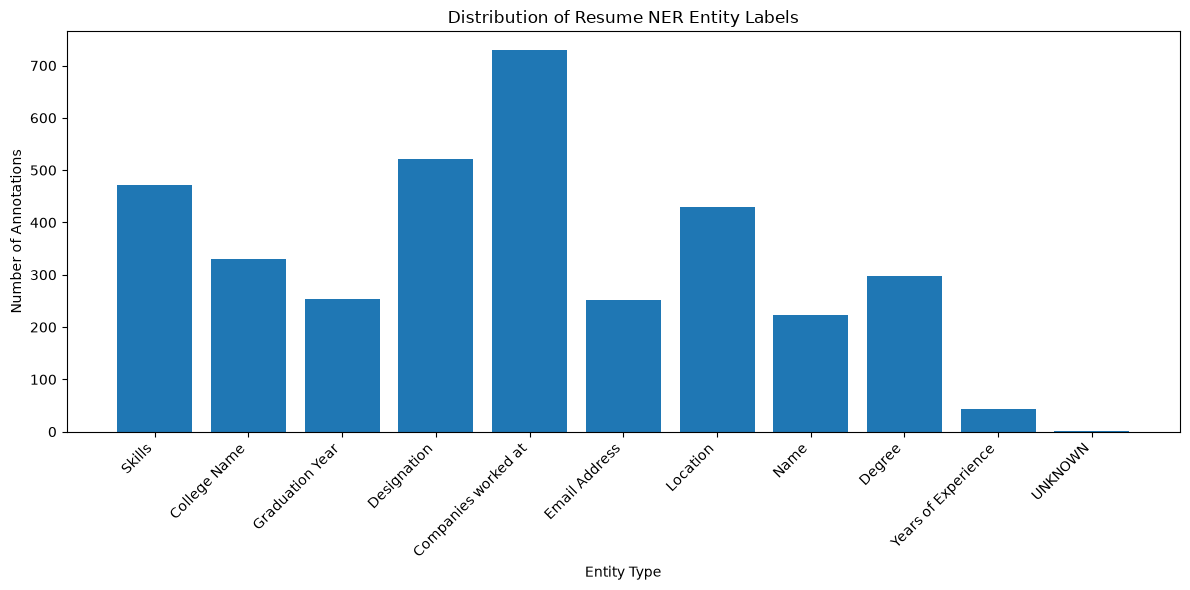

In [8]:
# Plot the entity distribution
import matplotlib.pyplot as plt

labels = list(label_counts.keys())
counts = list(label_counts.values())

plt.figure(figsize=(12, 6))
plt.bar(labels, counts)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Entity Type")
plt.ylabel("Number of Annotations")
plt.title("Distribution of Resume NER Entity Labels")
plt.tight_layout()
plt.show()

In [9]:
# Inspect records with "UNKNOWN" labels
for i, record in enumerate(records):
    for ann in record.get("annotation", []):
        if "UNKNOWN" in ann.get("label", []):
            print("Resume:", i)
            print(ann)
            print()

Resume: 61
{'label': ['UNKNOWN'], 'points': [{'start': 4262, 'end': 4281, 'text': 'Oracle 10g, 11g, 12c'}]}

Resume: 175
{'label': ['UNKNOWN'], 'points': [{'start': 2721, 'end': 2725, 'text': '2012\n'}]}



In [10]:
# Check for empty content, empty annotations, and invalid spans
empty_content = 0
empty_annotations = 0
invalid_spans = 0

for record in records:
    content = record.get("content", "")
    annotations = record.get("annotation", [])

    if not content.strip():
        empty_content += 1

    if len(annotations) == 0:
        empty_annotations += 1

    for ann in annotations:
        for point in ann.get("points", []):
            start = point.get("start")
            end = point.get("end")

            if start is None or end is None:
                invalid_spans += 1
            elif start < 0 or end >= len(content) or start > end:
                invalid_spans += 1

print("Empty resume text:", empty_content)
print("Resumes without annotations:", empty_annotations)
print("Invalid annotation spans:", invalid_spans)

Empty resume text: 0
Resumes without annotations: 0
Invalid annotation spans: 0


In [11]:
# Count how many resumes contain each entity type
resume_label_counts = Counter()

for record in records:
    labels_in_resume = set()

    for ann in record.get("annotation", []):
        for label in ann.get("label", []):
            labels_in_resume.add(label)

    for label in labels_in_resume:
        resume_label_counts[label] += 1

print("Number of resumes containing each entity:")
for label, count in resume_label_counts.most_common():
    print(f"{label}: {count}/{len(records)}")

Number of resumes containing each entity:
Name: 218/220
Designation: 202/220
Location: 199/220
College Name: 194/220
Degree: 192/220
Email Address: 190/220
Companies worked at: 190/220
Skills: 183/220
Graduation Year: 104/220
Years of Experience: 34/220
UNKNOWN: 2/220


## Clean and standardize the labels

In [12]:
# Make a cleaned copy of the dataset
import copy

cleaned_records = copy.deepcopy(records)

for record in cleaned_records:
    for ann in record.get("annotation", []):

        # Fix the two UNKNOWN labels
        if "UNKNOWN" in ann.get("label", []):
            text = ann["points"][0]["text"].strip()

            if text == "Oracle 10g, 11g, 12c":
                ann["label"] = ["Skills"]

            elif text == "2012":
                ann["label"] = ["Graduation Year"]

In [13]:
# Remove annotations with invalid spans
label_mapping = {
    "Name": "NAME",
    "College Name": "COLLEGE_NAME",
    "Companies worked at": "COMPANY",
    "Degree": "DEGREE",
    "Designation": "DESIGNATION",
    "Email Address": "EMAIL",
    "Graduation Year": "GRADUATION_YEAR",
    "Location": "LOCATION",
    "Skills": "SKILLS",
    "Years of Experience": "YEARS_OF_EXPERIENCE"
}

empty_label_count = 0

for record in cleaned_records:
    for ann in record.get("annotation", []):
        labels = ann.get("label", [])
        # Skip annotations with no label
        if not labels:
            empty_label_count += 1
            continue
        old_label = labels[0]
        ann["label"] = [label_mapping.get(old_label, old_label)]
print("Empty label annotations:", empty_label_count)

Empty label annotations: 2


In [14]:
# Check what those empty-label annotations actually are
for i, record in enumerate(cleaned_records):
    for ann in record.get("annotation", []):
        if not ann.get("label", []):
            print("Resume:", i)
            print(ann)
            print()

Resume: 81
{'label': [], 'points': [{'start': 2585, 'end': 2590, 'text': 'Oracle'}]}

Resume: 167
{'label': [], 'points': [{'start': 7878, 'end': 7882, 'text': 'B.B.M'}]}



In [15]:
# Check the surrounding résumé text
for resume_idx in [81, 167]:
    record = cleaned_records[resume_idx]
    content = record["content"]

    for ann in record.get("annotation", []):
        if not ann.get("label", []):
            point = ann["points"][0]

            start = point["start"]
            end = point["end"]

            context_start = max(0, start - 150)
            context_end = min(len(content), end + 150)

            print("\nResume:", resume_idx)
            print("Entity:", repr(point["text"]))
            print("Context:")
            print(content[context_start:context_end])
            print("-" * 80)


Resume: 81
Entity: 'Oracle'
Context:
OA, WebLogic and MFT
Module.

EDUCATION

C.S.

CHHATTISGARH SWAMI VIVEKANANDA TECHNICAL UNIVERSITY

2011 to 2015

SKILLS

Xml, Oracle MFT, Core Java, Oracle SOA, WSDL, ODI

ADDITIONAL INFORMATION

TECHNICAL SKILL SET
ERP Packages Oracle Fusion Middleware and Oracle Fusion Application (DOO/GOP)
Fusion Mid
--------------------------------------------------------------------------------

Resume: 167
Entity: 'B.B.M'
Context:
ions with key focus on bottom line profitability by ensuring
optimal utilization of available resources.
• Implementation &amp; Achievement of 5S for the Branch.

EDUCATION

B.B.M

Andhra University

2003

Gulmohar High School -  Jamshedpur, Jharkhand

2000
--------------------------------------------------------------------------------


In [16]:
# For Resume 81, Oracle is clearly a SKILLS entity because it appears inside the SKILLS / technical skills section of the résumé. For Resume 167, B.B.M is clearly a DEGREE entity because it appears inside the EDUCATION section of the résumé.
for record in cleaned_records:
    for ann in record.get("annotation", []):

        if not ann.get("label", []):
            text = ann["points"][0]["text"].strip()

            if text == "Oracle":
                ann["label"] = ["SKILLS"]

            elif text == "B.B.M":
                ann["label"] = ["DEGREE"]

In [17]:
# For B.B.M, we should still confirm its context before assigning DEGREE
resume_idx = 167
record = cleaned_records[resume_idx]
content = record["content"]

for ann in record.get("annotation", []):
    if not ann.get("label", []):
        point = ann["points"][0]

        start = point["start"]
        end = point["end"]

        print(content[max(0, start-100):min(len(content), end+100)])

In [18]:
# No output, that likely means B.B.M is no longer an empty-label annotation in current cleaned_records. Let's check the context of B.B.M in all resumes to be sure.
for i, record in enumerate(cleaned_records):
    for ann in record.get("annotation", []):
        for point in ann.get("points", []):
            if point.get("text", "").strip() == "B.B.M":
                
                start = point["start"]
                end = point["end"]
                content = record["content"]

                print("Resume:", i)
                print("Current label:", ann.get("label"))
                print("Entity:", repr(point["text"]))
                print("\nContext:")
                print(content[max(0, start-150):min(len(content), end+150)])

Resume: 167
Current label: ['DEGREE']
Entity: 'B.B.M'

Context:
ions with key focus on bottom line profitability by ensuring
optimal utilization of available resources.
• Implementation &amp; Achievement of 5S for the Branch.

EDUCATION

B.B.M

Andhra University

2003

Gulmohar High School -  Jamshedpur, Jharkhand

2000


In [19]:
# Ensure both are set correctly
for record in cleaned_records:
    for ann in record.get("annotation", []):

        labels = ann.get("label", [])
        text = ann["points"][0]["text"].strip()

        if not labels:
            if text == "Oracle":
                ann["label"] = ["SKILLS"]
            elif text == "B.B.M":
                ann["label"] = ["DEGREE"]

In [20]:
empty_labels = sum(
    1
    for record in cleaned_records
    for ann in record.get("annotation", [])
    if not ann.get("label", [])
)

print("Remaining empty labels:", empty_labels)

Remaining empty labels: 0


In [21]:
# Count how many annotations exist for each entity type in the cleaned dataset
from collections import Counter

final_label_counts = Counter()

for record in cleaned_records:
    for ann in record.get("annotation", []):
        for label in ann.get("label", []):
            final_label_counts[label] += 1

print("Final Entity Distribution:")
for label, count in final_label_counts.most_common():
    print(f"{label}: {count}")

Final Entity Distribution:
COMPANY: 729
DESIGNATION: 521
SKILLS: 474
LOCATION: 430
COLLEGE_NAME: 330
DEGREE: 299
GRADUATION_YEAR: 255
EMAIL: 252
NAME: 224
YEARS_OF_EXPERIENCE: 44


## Data spliting

In [22]:
# Use 80% train, 10% validation, 10% test.
# For 220 resumes, that gives: Train: 176 resumes, Validation: 22 resumes, Test: 22 resumes
from sklearn.model_selection import train_test_split

# 80% train, 20% temporary
train_records, temp_records = train_test_split(
    cleaned_records,
    test_size=0.20,
    random_state=42
)

# Split remaining 20% equally into 10% validation and 10% test
val_records, test_records = train_test_split(
    temp_records,
    test_size=0.50,
    random_state=42
)

print("Train:", len(train_records))
print("Validation:", len(val_records))
print("Test:", len(test_records))

Train: 176
Validation: 22
Test: 22


In [23]:
# Count how many annotations exist for each entity type in the train, validation, and test sets
from collections import Counter

def count_labels(records):
    counts = Counter()

    for record in records:
        for ann in record.get("annotation", []):
            for label in ann.get("label", []):
                counts[label] += 1

    return counts

train_counts = count_labels(train_records)
val_counts = count_labels(val_records)
test_counts = count_labels(test_records)

all_labels = sorted(final_label_counts.keys())

print(f"{'Entity':<25} {'Train':>8} {'Val':>8} {'Test':>8}")
print("-" * 52)

for label in all_labels:
    print(
        f"{label:<25} "
        f"{train_counts[label]:>8} "
        f"{val_counts[label]:>8} "
        f"{test_counts[label]:>8}"
    )

Entity                       Train      Val     Test
----------------------------------------------------
COLLEGE_NAME                   270       27       33
COMPANY                        619       50       60
DEGREE                         237       29       33
DESIGNATION                    412       51       58
EMAIL                          200       32       20
GRADUATION_YEAR                193       27       35
LOCATION                       343       44       43
NAME                           177       24       23
SKILLS                         408       26       40
YEARS_OF_EXPERIENCE             33        7        4


## Save split

In [24]:
# Save the train, validation, and test datasets to JSON files
import json
import os

os.makedirs("../data", exist_ok=True)

def save_json(records, filepath):
    with open(filepath, "w", encoding="utf-8") as f:
        json.dump(records, f, ensure_ascii=False, indent=2)

save_json(train_records, "../data/train.json")
save_json(val_records, "../data/val.json")
save_json(test_records, "../data/test.json")

print("Train, validation and test datasets saved successfully.")

Train, validation and test datasets saved successfully.


In [25]:
# Benchmark A and Benchmark B use the same data
print("Train:", len(train_records))
print("Validation:", len(val_records))
print("Test:", len(test_records))

Train: 176
Validation: 22
Test: 22
